In [1]:
from cirq_sic import *

# Visualizing state-spcae

In [2]:
d = 2
n = d**2
phi = load_sic_fiducial(d)
sic = d*wh_povm(phi)
P = np.array([[(sic[i]@sic[j]).trace() for j in range(n)] for i in range(n)]).real/d
Phi = (d+1)*np.eye(n) - (d/n)*np.ones((n,n))
R = np.array([[[(sic[i]@sic[j]@sic[k]).trace().real for k in range(n)] for j in range(n)] for i in range(n)])

A_matrices = np.einsum("ijk, kl->lij", R, Phi)
x_center = np.ones(n)/n

## 2D sections

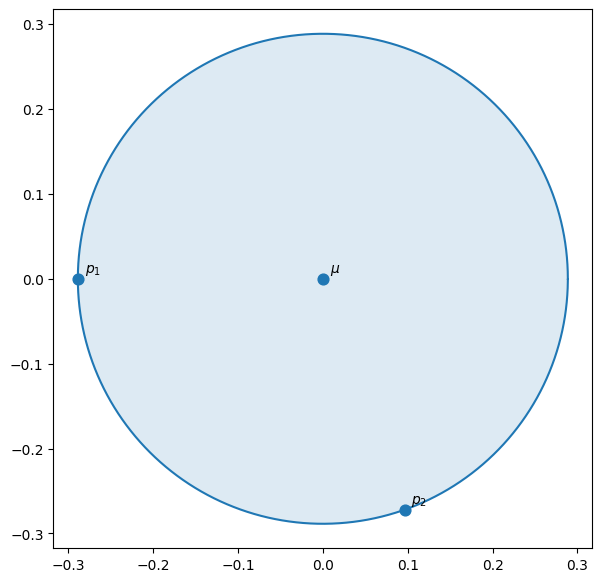

In [3]:
sic_indices = [0, 1]
marked_probabilities = [P[i] for i in sic_indices] + [x_center]
labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]

B = make_sum_zero_section(marked_probabilities[:-1])

section_data = probability_spectrahedron_section_2D(
        A_matrices=A_matrices,
        x_center=x_center,
        B=B,
        num_angles=1500,
)
section_data = section_data | {"marked_probabilities": marked_probabilities, "labels": labels}
plot_section_2D_matplotlib([section_data])

## 3D sections

In [8]:
sic_indices = [0,1,2]
marked_probabilities = [P[i] for i in sic_indices] + [x_center]
#marked_probabilities = [x_center]

#labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]
labels = ["p%d" % (i+1) for i in sic_indices] + ["mu"]
#labels = [r"$\mu$"]

B = make_sum_zero_section(marked_probabilities[:-1])
#B = make_sum_zero_section(np.random.randn(3, n))

section_data = probability_spectrahedron_section_3D(
        A_matrices=A_matrices,
        x_center=x_center,
        B=B,
)
section_data = section_data | {"marked_probabilities": marked_probabilities, "labels": labels}
#plot_section_3D_matplotlib([section_data])
plot_section_3D_plotly([section_data])

# Comparison

In [9]:
base_dir = 'tmp_triple_products'

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)
print("sanity check: %s" % np.allclose(R, exactify(task)['T'], atol=1e-4, rtol=1e-4))

run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)

R_empirical = np.array(results["processed_data"]["T"])
P_empirical = np.sum(R_empirical, axis=0) / d**2
Phi_empirical = np.linalg.pinv(P_empirical)
A_matrices_empirical = np.einsum("ijk, kl->lij", R_empirical, Phi_empirical)

sanity check: True
2026-07-21 17:13:44 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Starting task...
2026-07-21 17:13:44 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Creating circuits...
2026-07-21 17:13:44 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Optimizing circuits...
2026-07-21 17:13:53 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Sampling...
2026-07-21 17:13:53 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Processing results...
2026-07-21 17:13:53 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Saving...


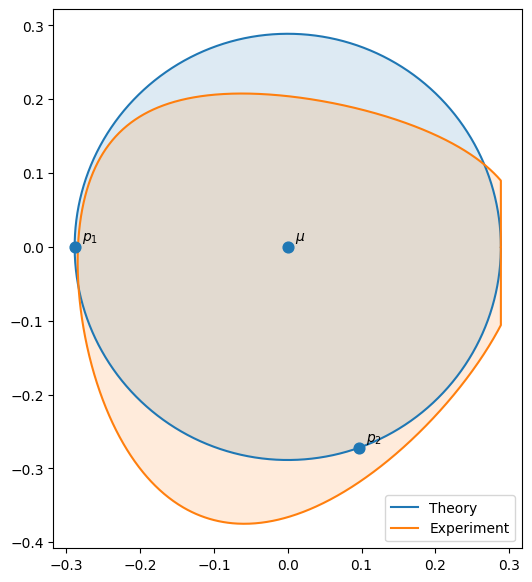

In [11]:
sic_indices = [0, 1]
marked_probabilities = [P[i] for i in sic_indices] + [x_center]
labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]

B = make_sum_zero_section(marked_probabilities[:-1])

section_data = probability_spectrahedron_section_2D(
        A_matrices=A_matrices,
        x_center=x_center,
        B=B,
        num_angles=1500,
)
section_data = section_data | {"marked_probabilities": marked_probabilities, "labels": labels}

section_data_empirical = probability_spectrahedron_section_2D(
        A_matrices=A_matrices_empirical,
        x_center=x_center,
        B=B,
        num_angles=1500,
)
section_data_empirical = section_data_empirical | {"marked_probabilities": [], "labels": []}
plot_section_2D_matplotlib([section_data, section_data_empirical], section_labels=["Theory", "Experiment"])

In [12]:
sic_indices = [0,1,2]
marked_probabilities = [P[i] for i in sic_indices] + [x_center]
labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]
B = make_sum_zero_section(marked_probabilities[:-1])

section_data = probability_spectrahedron_section_3D(
        A_matrices=A_matrices,
        x_center=x_center,
        B=B,
)
section_data = section_data | {"marked_probabilities": marked_probabilities, "labels": labels}

section_data_empirical = probability_spectrahedron_section_3D(
        A_matrices=A_matrices_empirical,
        x_center=x_center,
        B=B,
)
section_data_empirical = section_data_empirical | {"marked_probabilities": [], "labels": []}

#plot_section_3D_matplotlib([section_data, section_data_empirical], section_labels=["Theory", "Experiment"])
plot_section_3D_plotly([section_data, section_data_empirical], section_labels=["Theory", "Experiment"])
